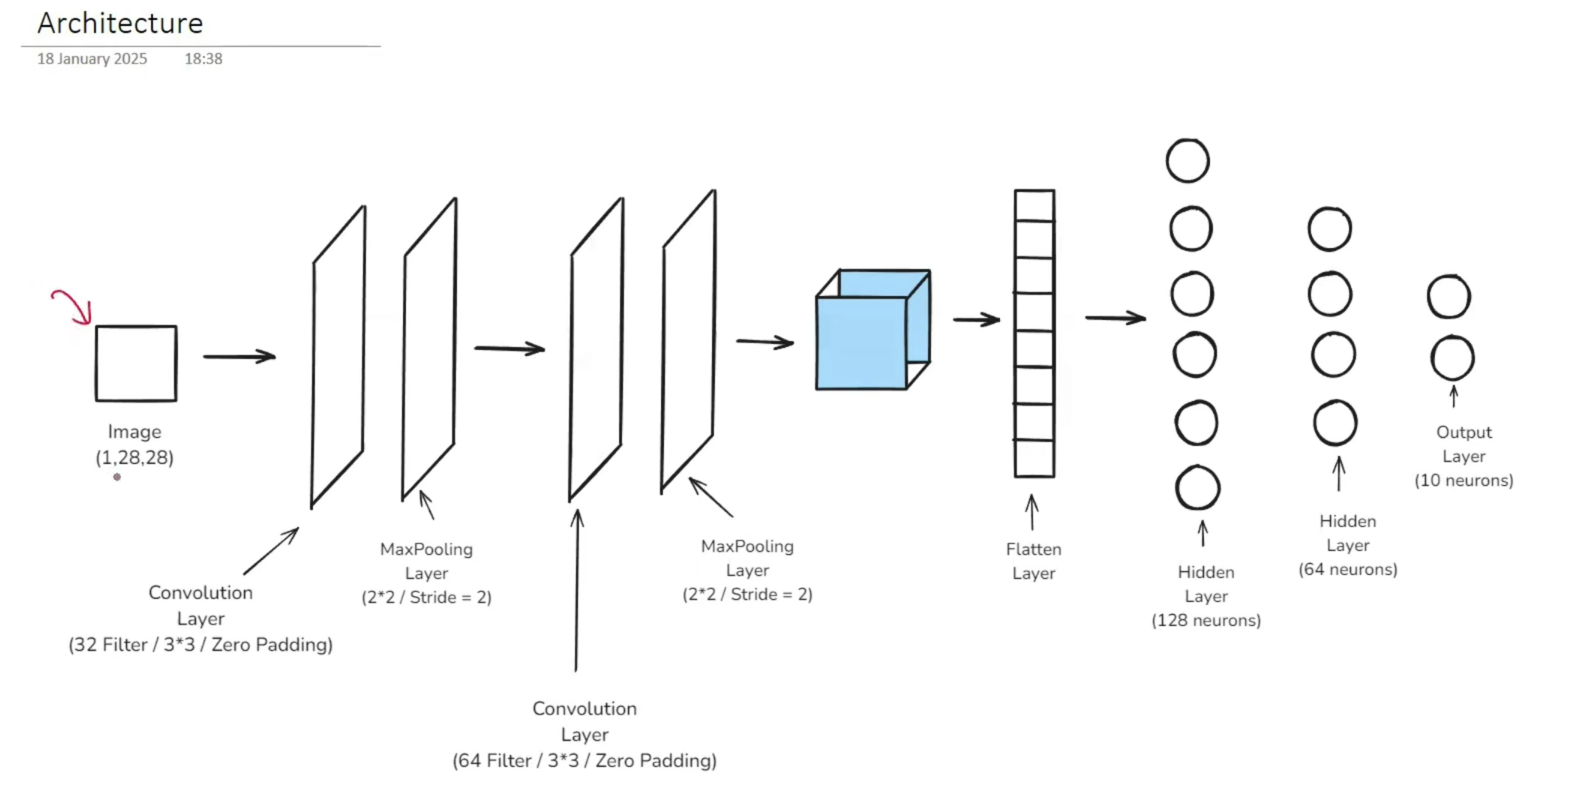

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [29]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [30]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [31]:
df = pd.read_csv('fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
df.shape

(60000, 785)

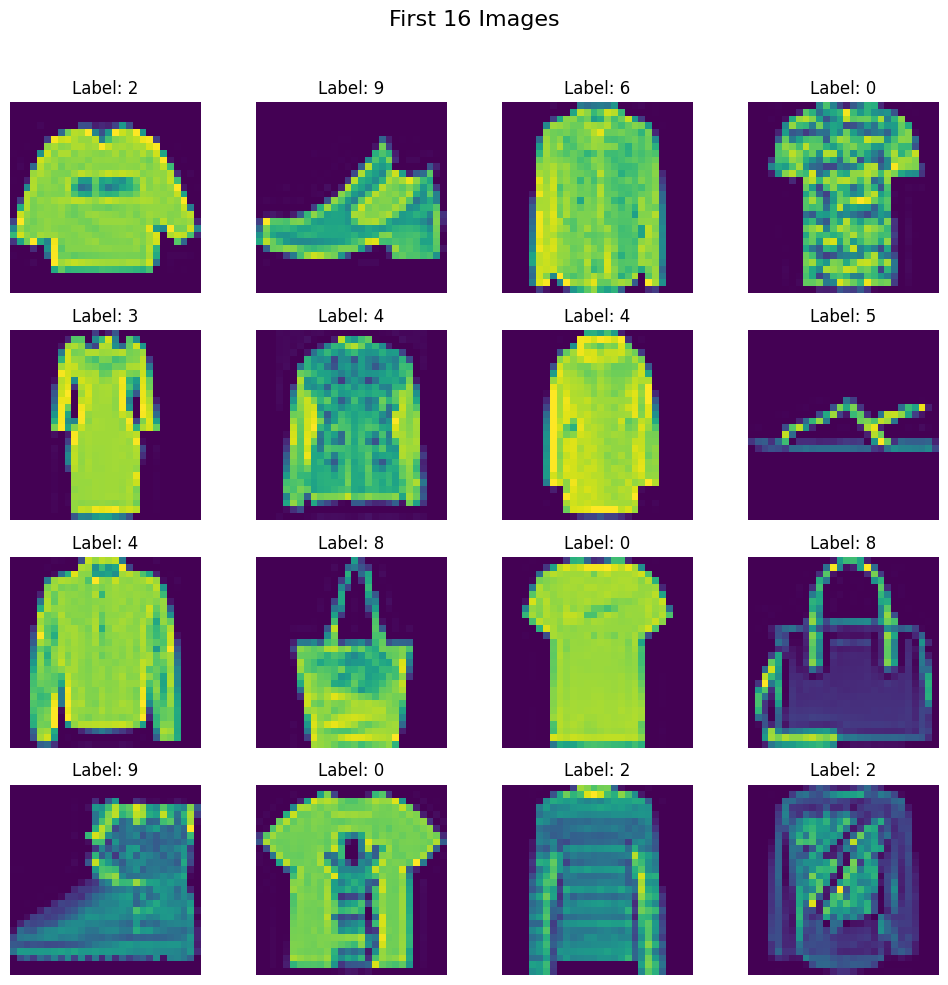

In [33]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [34]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
X_train = X_train/255.0
X_test = X_test/255.0

In [37]:
# THIS DATASET CLASS FETCH ONE ROW FROM DATASET [WHICH IS ONE-D] SO WE WILL CHANGE THINGS AS PER THE NEED NOW
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    # Convert to PyTorch tensors
    # self.features = torch.tensor(features, dtype=torch.float32)
    # self.labels = torch.tensor(labels, dtype=torch.long)
    # WE NEED TO RESHAPE THE FEATURE WHICH WE EXTRACT IN 1,28,28 [784[1-d]  -> 28*28[2-d]]
    # WE ALSO NEED TO PASS THE BATCH_SIZE [HOW MANY ROWS] - HERE -1 IS PLACEHOLDER
    # LATER when we will create the dataloader obj it will be auto-inferred to 32
    self.features = torch.tensor(features, dtype=torch.float32).reshape(-1, 1, 28, 28)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]


In [38]:
train_dataset = CustomDataset(X_train, y_train)

In [39]:
test_dataset = CustomDataset(X_test, y_test)

In [40]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [52]:
# NN-Architecture [CNN]
class MyNN(nn.Module):
  def __init__(self, input_features):
    super().__init__()

    # Arch -> feature extraction + classification
    # will create two sequential containers containing layers
    self.features = nn.Sequential(
        # will add CONVOLUTION and POOLING layers and it is going to be pairs as per arch above
        nn.Conv2d(input_features, 32, kernel_size=3, padding='same'),
        nn.ReLU(),
        # batch normalization
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(32, 64, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.classifier = nn.Sequential(
        # we flatten that tensor we get after the pair of layers
        nn.Flatten(),
        # but we must know the shape of the tensor to get the number of input we pass
        # we are passing (1,28,28) and since we are using padding so size would remain
        # but due to filter size(32)  it will changed to -> (32, 28, 28) channels will change[1->32]
        # pooling [image_size -> half as we are using pooling layer is 2*2 and strider is 2] channel remains same
        #  so we get -> (32, 14, 14)

        # now second pair []
        # since padding is there so channel will be changed -> (64, 14, 14)
        # after pooling [2*2 and stride=2] -> (64, 7, 7)
        # so finally the tensor shape will be (64. 7, 7) -> will be flattened and used as input for first layer
        # above is just expln : it can be coded
        nn.Linear(64*7*7, 128),
        nn.ReLU(),
        # we can use dropouts as well
        nn.Dropout(p=0.4),

        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(p=0.4),
        nn.Linear(64, 10)
    )

    # FORWARD PASS IN TWO PHASES :
    # -> first our image will move through features extraction
    # -> then classifier
  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x


In [53]:
learning_rate = 0.01
epochs = 100

In [54]:
# model = MyNN(X_train.shape[1])
# we will send 1 for input channel
model = MyNN(1)

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [55]:
# NO CHANGE
# training loop

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = model(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


Epoch: 1 , Loss: 0.6575068029165267
Epoch: 2 , Loss: 0.3888957610527674
Epoch: 3 , Loss: 0.3273562849164009
Epoch: 4 , Loss: 0.29356581159184375
Epoch: 5 , Loss: 0.2677858037961026
Epoch: 6 , Loss: 0.24543054416775703
Epoch: 7 , Loss: 0.23264433947950602
Epoch: 8 , Loss: 0.21532216824094455
Epoch: 9 , Loss: 0.20236081360280514
Epoch: 10 , Loss: 0.1923719641355177
Epoch: 11 , Loss: 0.180158174664403
Epoch: 12 , Loss: 0.16739591323708494
Epoch: 13 , Loss: 0.16058784429791073
Epoch: 14 , Loss: 0.1543015815714995
Epoch: 15 , Loss: 0.14665156698475282
Epoch: 16 , Loss: 0.140828972062096
Epoch: 17 , Loss: 0.13093430827061336
Epoch: 18 , Loss: 0.12330117877696951
Epoch: 19 , Loss: 0.11670027934201062
Epoch: 20 , Loss: 0.10993732488884901
Epoch: 21 , Loss: 0.10666970736626535
Epoch: 22 , Loss: 0.10272662881668657
Epoch: 23 , Loss: 0.09565582668889935
Epoch: 24 , Loss: 0.0889920650141236
Epoch: 25 , Loss: 0.08760545947515251
Epoch: 26 , Loss: 0.0839462879402175
Epoch: 27 , Loss: 0.0812210324245

In [56]:
model.eval()

MyNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [57]:
# Evaluation on TEST DATA
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9235


In [58]:
# Evaluation TRAINING DATA
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.999875
